# Simple Linear Regression

## Install/Upgrade Dependencies

**What & why:** install the core Python ML/data-science stack.
- `pandas` / `numpy` — load and manipulate tabular data
- `seaborn` / `matplotlib` — visualize data (spot patterns, outliers, relationships)
- `scikit-learn` — the ML library: model classes (`LinearRegression`), splitting helpers (`train_test_split`), and evaluation metrics (`metrics` module)

In [13]:
!pip install --upgrade pandas numpy seaborn matplotlib scikit-learn

## Data Loading & Exploration

**EDA (Exploratory Data Analysis):** before training any model, get to know the data. This tells you what preprocessing is needed and whether the data suits the model (linear regression assumes roughly linear relationships and numeric features).
- `tail()` / `head()` — sanity check the raw values look sensible
- `shape` — number of rows (samples) and columns (features + target)
- `columns` — feature/target names
- `info()` — data types (must be numeric for `LinearRegression`) + non-null counts
- `isnull().sum()` — missing values; models can't train on NaNs, must clean/impute first
- `describe()` — mean/std/min/max/quartiles; spot scale differences & possible outliers
- `duplicated()` — duplicate rows can bias training and inflate performance metrics

In [14]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn import metrics


def section(title):
    print("\n" + "=" * 60)
    print(title)
    print("=" * 60)


# Read CSV
df = pd.read_csv("data/advertising.csv")

section("LAST 5 ROWS")
print(df.tail())

section("SHAPE")
print("Shape:", df.shape)

section("COLUMNS")
print("Columns:", df.columns.tolist())

section("DATA TYPES & INFO")
print(df.info())

section("MISSING VALUES")
print(df.isnull().sum())

section("STATISTICAL SUMMARY")
print(df.describe())

section("DUPLICATE ROWS")
print("Duplicate rows:", df.duplicated().sum())



LAST 5 ROWS
        TV  Radio  Newspaper  Sales
195   38.2    3.7       13.8    7.6
196   94.2    4.9        8.1   14.0
197  177.0    9.3        6.4   14.8
198  283.6   42.0       66.2   25.5
199  232.1    8.6        8.7   18.4

SHAPE
Shape: (200, 4)

COLUMNS
Columns: ['TV', 'Radio', 'Newspaper', 'Sales']

DATA TYPES & INFO
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   TV         200 non-null    float64
 1   Radio      200 non-null    float64
 2   Newspaper  200 non-null    float64
 3   Sales      200 non-null    float64
dtypes: float64(4)
memory usage: 6.4 KB
None

MISSING VALUES
TV           0
Radio        0
Newspaper    0
Sales        0
dtype: int64

STATISTICAL SUMMARY
               TV       Radio   Newspaper       Sales
count  200.000000  200.000000  200.000000  200.000000
mean   147.042500   23.264000   30.554000   15.130500
std     85.854236   14.

## Pair Plot Visualization

**Why visualize relationships:** for linear regression, check whether the feature(s) (TV/Radio/Newspaper) have a roughly straight-line relationship with the target (Sales) — that's the model's core assumption. The diagonal histograms show each variable's own distribution (spread/skew).

<Figure size 1200x1000 with 0 Axes>

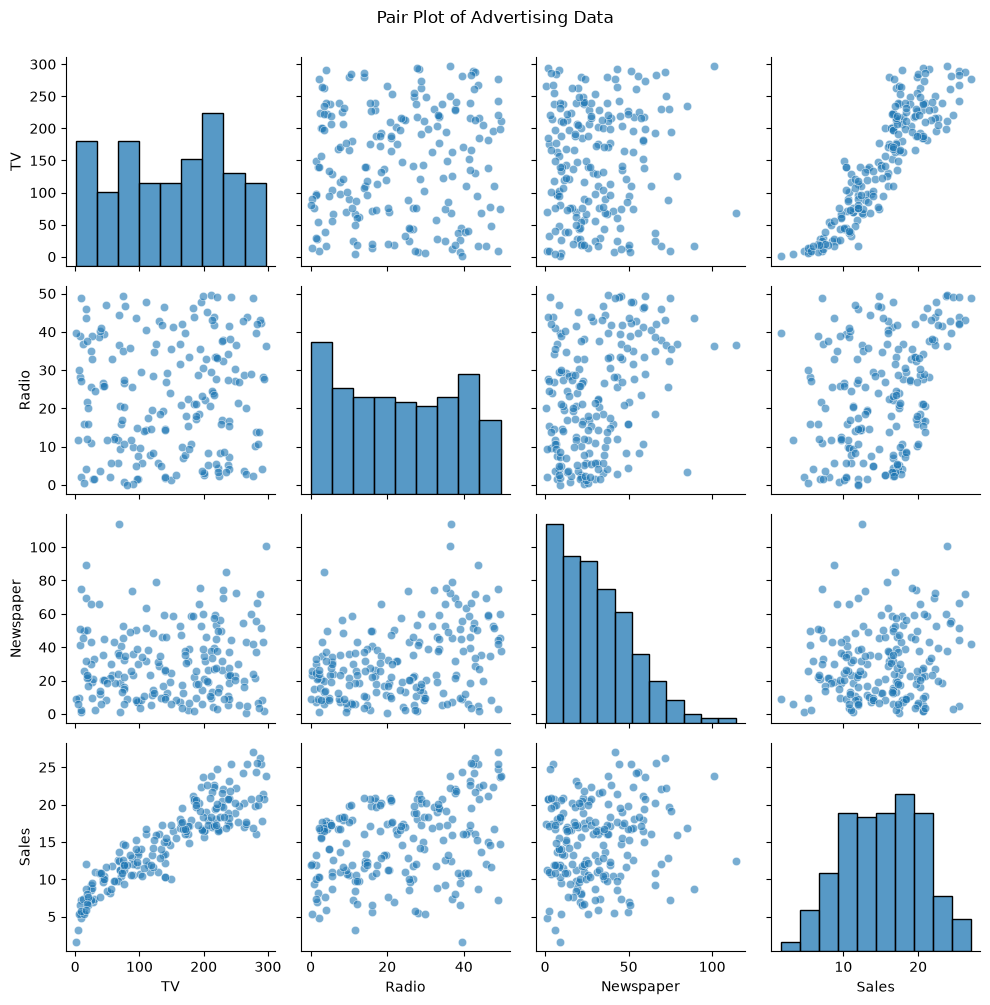

In [15]:
# Generate Pair Plot
plt.figure(figsize=(12, 10))
pair_plot = sns.pairplot(df, diag_kind="hist", plot_kws={"alpha": 0.6})
pair_plot.fig.suptitle("Pair Plot of Advertising Data", y=1.00)
plt.tight_layout()
plt.show()

## Feature and Target Selection

**Choosing X and y:** this is *simple* linear regression because there is only one feature (TV). (Compare to Day 12's multiple linear regression, which uses TV + Radio + Newspaper.)
- `X` must be 2D (rows = samples, cols = features) — use double brackets `df[["TV"]]` so it stays a DataFrame even with one feature.
- `y` can stay 1D — a single column/Series — since it's the target we want to predict.

In [16]:
# TV sales can include linear regression model to predict sales based on TV advertising budget.
X = df[["TV"]]  # 2D DataFrame for sklearn
y = df["Sales"]  # 1D Series target

## Box Plot & Statistics for TV Budget

**Check distribution & outliers:** a box plot shows the median, quartiles (the box), and outliers (points beyond the whiskers). Outliers can pull a linear regression line away from the typical trend, since it fits by minimizing squared error.

C:\Users\laksh\AppData\Local\Temp\ipykernel_9596\2517386654.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(y=df["TV"], palette="Set2")


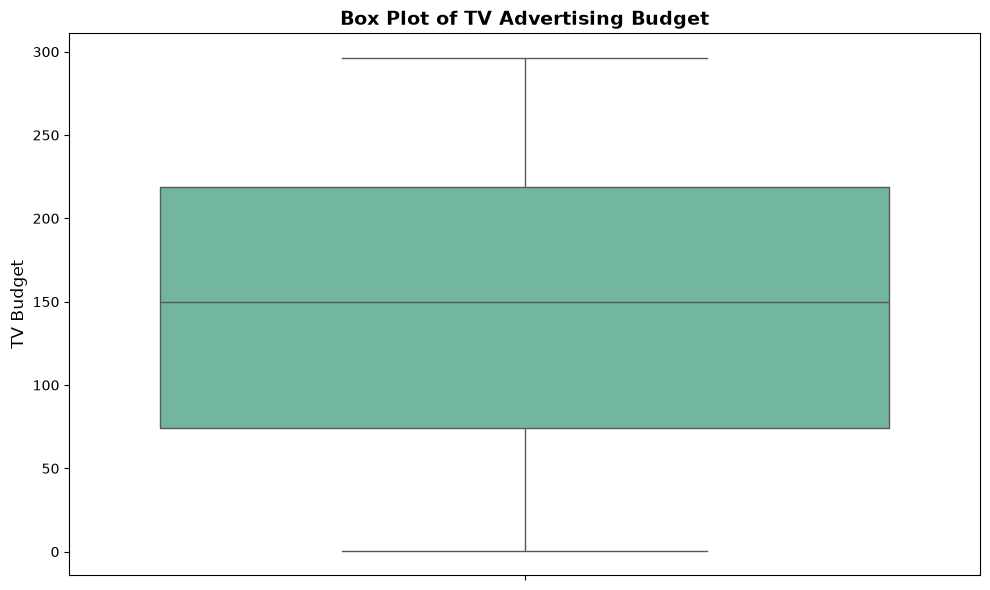


TV STATISTICS
Min: 0.7
Max: 296.4
Mean: 147.04
Median: 149.75
Std Dev: 85.85


In [17]:
# Generate Box Plot for TV
plt.figure(figsize=(10, 6))
sns.boxplot(y=df["TV"], palette="Set2")
plt.title("Box Plot of TV Advertising Budget", fontsize=14, fontweight="bold")
plt.ylabel("TV Budget", fontsize=12)
plt.tight_layout()
plt.show()

section("TV STATISTICS")
print(f"Min: {df['TV'].min()}")
print(f"Max: {df['TV'].max()}")
print(f"Mean: {df['TV'].mean():.2f}")
print(f"Median: {df['TV'].median()}")
print(f"Std Dev: {df['TV'].std():.2f}")


## Train-Test Split

**Why split the data:** train on one portion, test on a separate unseen portion to check generalization — never evaluate on data the model trained on, that only measures memorization.
- `test_size=0.2` — 20% of rows held out for testing, 80% for training
- `random_state=42` — fixes the random shuffle so the split is reproducible

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

section("TRAIN/TEST SPLIT")
print(f"Training set size: {X_train.shape[0]} samples")
print(f"Testing set size: {X_test.shape[0]} samples")



TRAIN/TEST SPLIT
Training set size: 160 samples
Testing set size: 40 samples


## Model Training

**What `.fit()` does:** linear regression fits a straight line `Sales = weight * TV + intercept` by finding the weight and intercept that minimize the sum of squared differences between actual and predicted Sales on the training data (the "least squares" method). `.fit(X_train, y_train)` is where the actual learning happens — everything before this prepared the data, everything after evaluates it.

In [19]:
lr_model = LinearRegression()
lr_model.fit(X_train, y_train)

lr_model.weights = lr_model.coef_[0] # Slope of the regression line

section("MODEL PARAMETERS")
print(f"Coefficient (Weight): {lr_model.weights:.4f}")  # Slope of the regression line
print(f"Intercept: {lr_model.intercept_:.4f}")  # Intercept of the regression line



MODEL PARAMETERS
Coefficient (Weight): 0.0555
Intercept: 7.0071


## Overfitting Check (Train vs Test R²)

**Reading R² for overfitting:** `.score()` for a regression model returns R² (coefficient of determination) — the proportion of variance in Sales explained by the model, from 0 to 1 (1 = perfect fit, 0 = no better than predicting the mean of y).
- Train >> Test → **overfitting** (memorized training data, doesn't generalize)
- Train ≈ Test → good generalization
- Both scores low → **underfitting** (model too simple / missing signal)

In [20]:
# Overfitting check: Train and Test Scores
train_score = lr_model.score(X_train, y_train)
test_score = lr_model.score(X_test, y_test)

section("OVERFITTING CHECK (R^2 SCORES)")
print(f"Training Score (R^2): {train_score:.4f}")
print(f"Testing Score (R^2): {test_score:.4f}")



OVERFITTING CHECK (R^2 SCORES)
Training Score (R^2): 0.8135
Testing Score (R^2): 0.8026


## RMSE Evaluation

**RMSE (Root Mean Squared Error):** measures typical prediction error in the same units as the target (Sales). It squares each error before averaging, so large errors/outliers are penalized more heavily than with MAE. Lower is better — compute on both train and test to compare the same way as R².

In [21]:
# Train RMSE
train_predictions = lr_model.predict(X_train)
train_rmse = np.sqrt(metrics.mean_squared_error(y_train, train_predictions))

# Test RMSE
test_predictions = lr_model.predict(X_test)
test_rmse = np.sqrt(metrics.mean_squared_error(y_test, test_predictions))

section("RMSE (ROOT MEAN SQUARED ERROR)")
print(f"Train RMSE: {train_rmse:.4f}")
print(f"Test RMSE: {test_rmse:.4f}")



RMSE (ROOT MEAN SQUARED ERROR)
Train RMSE: 2.2357
Test RMSE: 2.4700


## MAE Evaluation

**MAE (Mean Absolute Error):** the average of the absolute differences between actual and predicted Sales, also in the target's units. Unlike RMSE, it doesn't square errors, so it's less sensitive to outliers and easier to interpret ("on average, predictions are off by this much").

In [22]:
section("MAE")
print(f"Train MAE: {metrics.mean_absolute_error(y_train, train_predictions):.4f}")
print(f"Test MAE: {metrics.mean_absolute_error(y_test, test_predictions):.4f}")



MAE
Train MAE: 1.8005
Test MAE: 1.9503


## R² Score Summary

**Recap:** R² is repeated here as the final summary metric because it's scale-free (always 0–1), making it the easiest of the three metrics to judge "is this a good model?" at a glance, while RMSE/MAE tell you the error size in real Sales units.

In [23]:
section("R2 Score")
print(f"Train R2 Score: {lr_model.score(X_train, y_train):.4f}")
print(f"Test R2 Score: {lr_model.score(X_test, y_test):.4f}")



R2 Score
Train R2 Score: 0.8135
Test R2 Score: 0.8026


## Prediction on New Data

**Making a prediction:** use the trained model on brand-new, real-world input. The new data must be shaped like the training features — a DataFrame with the same column name `"TV"` — since that's the contract sklearn's `.predict()` expects. This is the actual point of building the model — everything above prepared and validated it.

In [24]:
# Prediction x = 200
section("PREDICT")
tv_budget = 200
prediction = lr_model.predict(
    pd.DataFrame({"TV": [tv_budget]})
)
print(f"TV Advertising Budget: {tv_budget}")
print(f"Predicted Sales: {prediction[0]:.4f}")



PREDICT
TV Advertising Budget: 200
Predicted Sales: 18.1037
